<a href="https://colab.research.google.com/github/asolergayoso/DS_5500_Ransomware_Detection/blob/tsnse_and_basic_classification/vis_and_class_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install umap-learn

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from umap import UMAP
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [ ]:
df = pd.read_pickle("/content/final_dataset_with_all_logs_window_10s.pkl")
df.drop(["start", "end"], axis=1, inplace=True)
df["is_ransomware"] = df["is_ransomware"].astype(int)
print(df.isna().sum())
df.fillna(-1, inplace=True)

features = df.drop(['is_ransomware', 'operation'], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

df_scaled['is_ransomware'] = df['is_ransomware']
df_scaled['operation'] = df['operation']

display(df_scaled.head())

avg_ata_read                         0
avg_ata_write                        0
lba_read_var                       808
lba_write_var                       28
avg_storage_entropy                 28
avg_entropy_mem_write                0
avg_entropy_mem_read_write        7393
num_4KB_pages_mem_read               0
num_4KB_pages_mem_write              0
num_4KB_pages_mem_read_write         0
num_4KB_pages_mem_exec               0
num_2MB_pages_mem_read               0
num_2MB_pages_mem_write              0
num_2MB_pages_mem_read_write         0
num_2MB_pages_mem_exec               0
num_MMIO_pages_mem_read              0
num_MMIO_pages_mem_write             0
num_MMIO_pages_mem_read_write        0
num_MMIO_pages_mem_exec              0
gpa_mem_read_var                     0
gpa_mem_write_var                    0
gpa_mem_read_write_var            9940
gpa_mem_exec_var                 18982
is_ransomware                        0
operation                            0
operation_log_cnt        

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,num_MMIO_pages_mem_exec,gpa_mem_read_var,gpa_mem_write_var,gpa_mem_read_write_var,gpa_mem_exec_var,operation_log_cnt,start_s,end_s,is_ransomware,operation
0,-0.878368,-0.502212,0.418015,1.446157,0.586694,2.924801,0.799593,2.043335,-0.145777,-0.12222,...,0.0,6.034777,6.036863,1.519211,4.527526,-1.568083,-1.688739,-1.688739,0,AESCrypt
1,-0.878368,-0.502212,0.418015,1.446157,0.586694,0.122166,0.597661,-0.060666,-0.145777,-0.12222,...,0.0,0.605069,-0.079213,0.629595,4.038746,-1.568083,-1.671418,-1.671418,0,AESCrypt
2,-0.739546,-0.502171,-0.218869,1.453851,0.578538,-0.377586,-1.431898,-0.323667,-0.145777,-0.12222,...,0.0,-0.094069,-0.099053,-0.469833,1.139075,-1.568083,-1.654098,-1.654098,0,AESCrypt
3,-0.691832,-0.505780,-0.212883,-1.258390,-0.754795,-0.099736,0.652251,-0.323667,-0.145777,-0.12222,...,0.0,-0.016899,-0.093528,1.918065,0.794245,-1.568083,-1.636777,-1.636777,0,AESCrypt
4,-0.682928,-0.505861,-0.218298,-1.745168,-0.898956,-0.093737,0.652251,-0.323667,-0.145777,-0.12222,...,0.0,-0.012532,-0.091968,1.918065,0.794245,-1.568083,-1.619456,-1.619456,0,AESCrypt


# **Visualizations**

The following are some visualizations of the dataset using different dimensionality reduction techniques

### TSNE

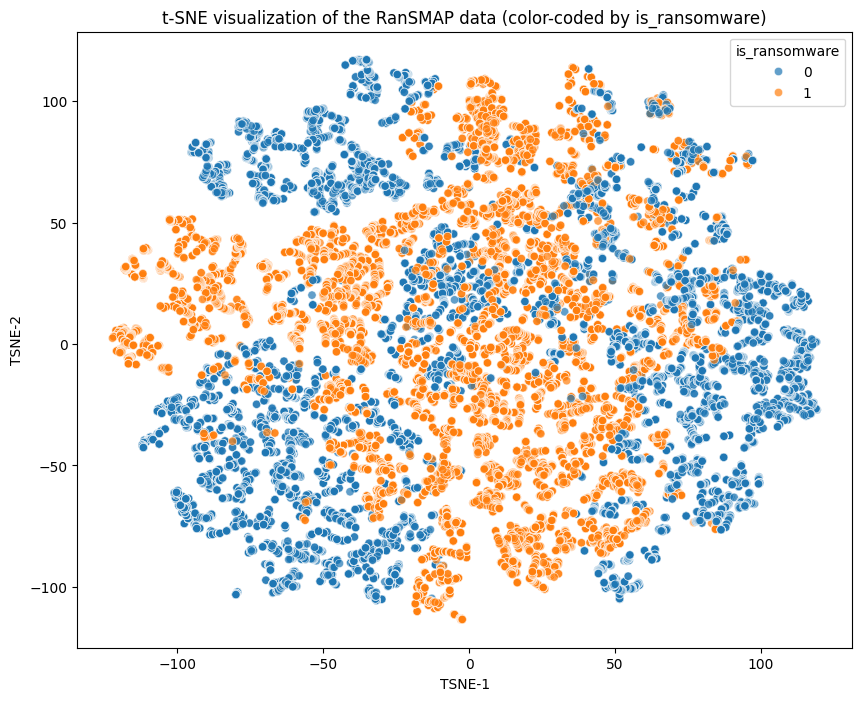

,TSNE-1,TSNE-2,is_ransomware,operation
0,67.111526,100.063988,0,True
1,75.533409,79.328201,0,True
2,73.668701,71.443214,0,True
3,72.025070,77.502449,0,True
4,71.928185,77.468460,0,True


In [ ]:
tsne_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(tsne_features)

df_tsne = pd.DataFrame(tsne_results, columns=['TSNE-1', 'TSNE-2'])
df_tsne['is_ransomware'] = df_scaled['is_ransomware']
df_tsne['operation'] = df_scaled['operation'].astype(bool)


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="is_ransomware",
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of the RanSMAP data (color-coded by is_ransomware)')
plt.show()

display(df_tsne.head())

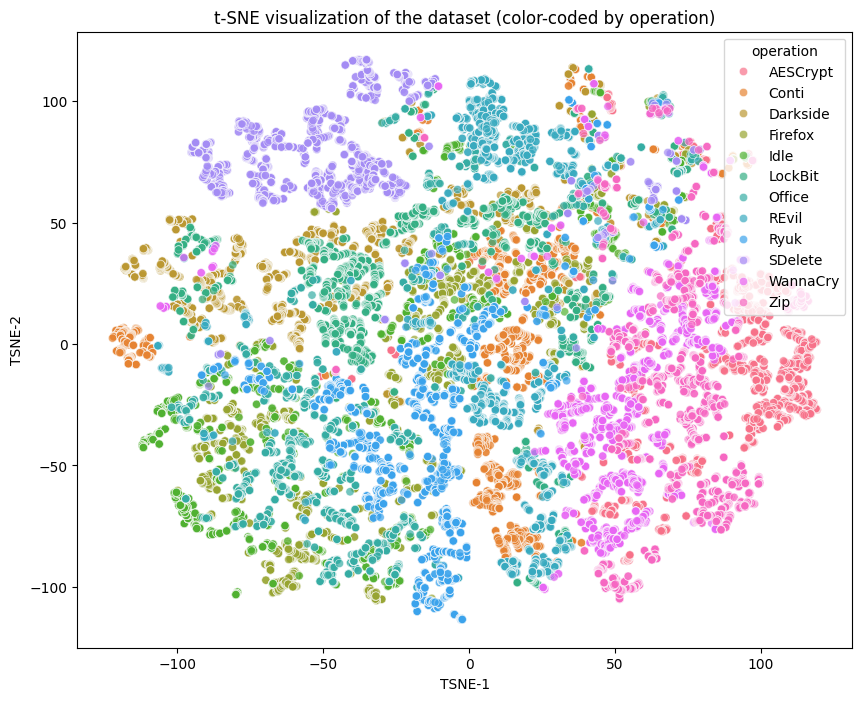

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="operation",
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of the dataset (color-coded by operation)')
plt.show()


## PCA with 2 components

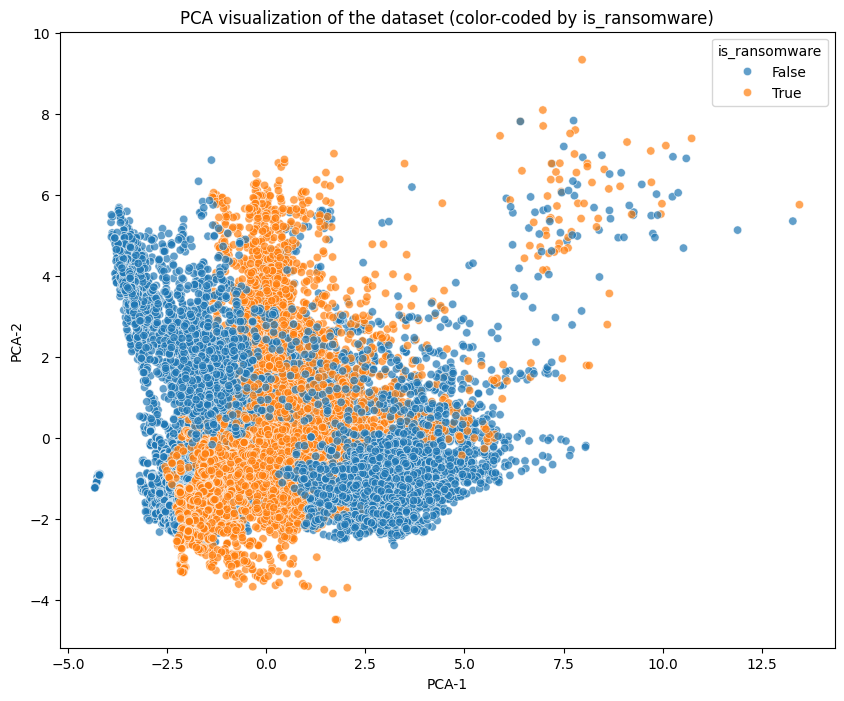

,PCA-1,PCA-2,is_ransomware
0,8.880858,4.948612,False
1,1.393000,1.483011,False
2,-0.629553,0.289743,False
3,0.291450,1.035749,False
4,0.270638,1.067765,False


In [ ]:
pca_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(pca_features)

df_pca = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2'])
df_pca['is_ransomware'] = df_scaled['is_ransomware'].astype(bool)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="PCA-1", y="PCA-2",
    hue="is_ransomware",
    data=df_pca,
    legend="full",
    alpha=0.7
)
plt.title('PCA visualization of the dataset (color-coded by is_ransomware)')
plt.show()

display(df_pca.head())

## PCA with 3 components

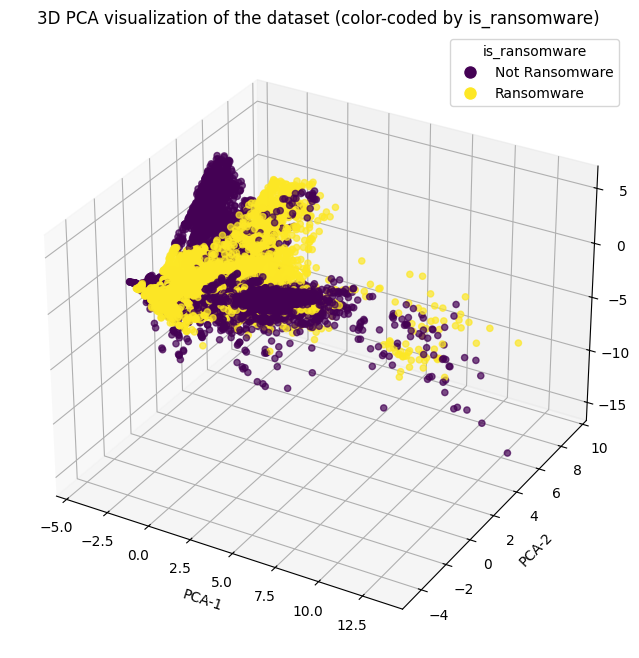

,PCA-1,PCA-2,PCA-3,is_ransomware
0,8.880858,4.948612,-9.700393,0
1,1.393000,1.483011,-4.432299,0
2,-0.629553,0.289743,-3.414014,0
3,0.291450,1.035749,-2.882047,0
4,0.270638,1.067765,-2.776814,0


In [ ]:
pca_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

pca = PCA(n_components=3, random_state=42)
pca_results = pca.fit_transform(pca_features)

df_pca_3d = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2', 'PCA-3'])
df_pca_3d['is_ransomware'] = df_scaled['is_ransomware']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pca_3d['PCA-1'],
    df_pca_3d['PCA-2'],
    df_pca_3d['PCA-3'],
    c=df_pca_3d['is_ransomware'],
    cmap='viridis',
    alpha=0.7
)

ax.set_xlabel('PCA-1')
ax.set_ylabel('PCA-2')
ax.set_zlabel('PCA-3')
plt.title('3D PCA visualization of the dataset (color-coded by is_ransomware)')

legend_labels = {0: 'Not Ransomware', 1: 'Ransomware'}
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markerfacecolor=scatter.cmap(scatter.norm(value)), markersize=10)
           for value, label in legend_labels.items()]
ax.legend(handles=handles, title='is_ransomware')

plt.show()

display(df_pca_3d.head())

## UMAP

In [ ]:
umap_model = UMAP(n_components=2, random_state=42)

umap_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

umap_results = umap_model.fit_transform(umap_features)

df_umap = pd.DataFrame(umap_results, columns=['UMAP-1', 'UMAP-2'])

df_umap['is_ransomware'] = df_scaled['is_ransomware'].astype(bool)
df_umap['operation'] = df_scaled['operation']

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


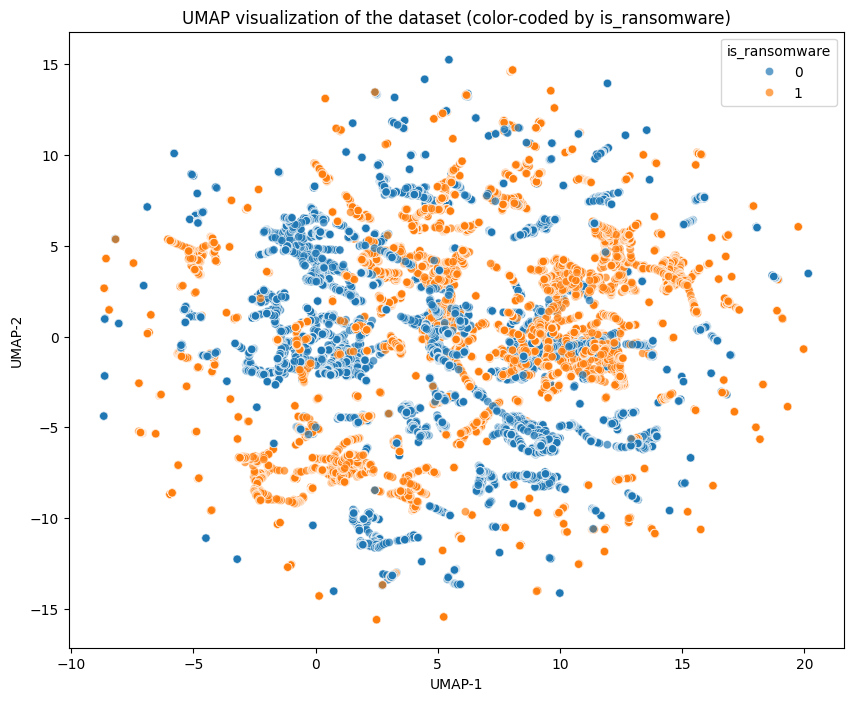

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="UMAP-1", y="UMAP-2",
    hue="is_ransomware",
    data=df_umap,
    legend="full",
    alpha=0.7
)
plt.title('UMAP visualization of the dataset (color-coded by is_ransomware)')
plt.show()


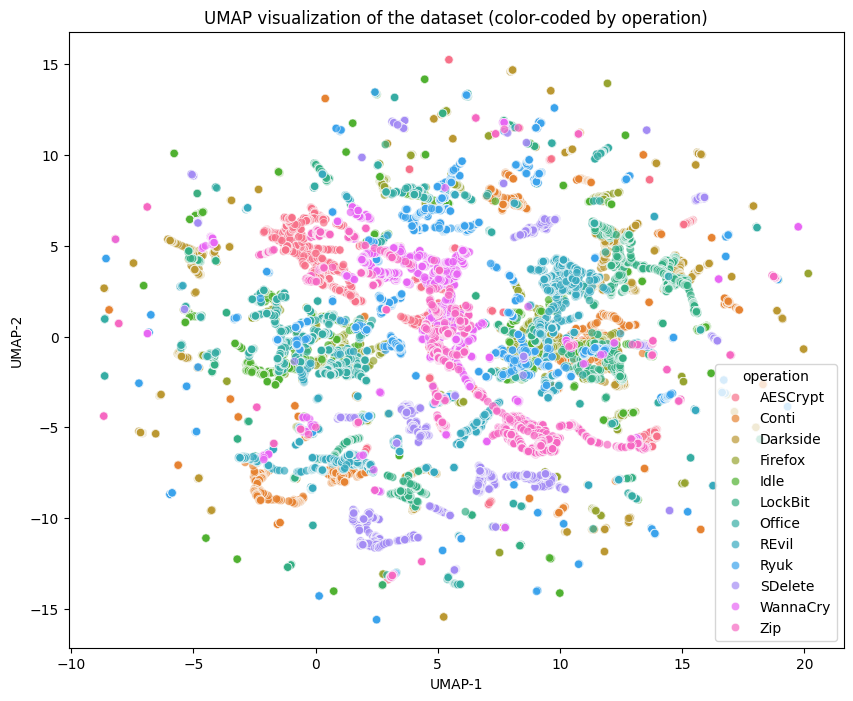

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="UMAP-1", y="UMAP-2",
    hue="operation",
    data=df_umap,
    legend="full",
    alpha=0.7
)
plt.title('UMAP visualization of the dataset (color-coded by operation)')
plt.show()

# **Classification**

Different models will be trained with the scaled data to get a basic sense of accuracy

In [ ]:
unseen_target = df_scaled[df["operation"].isin(["WannaCry", "Firefox"])]['is_ransomware']
unseen_features = df_scaled[df["operation"].isin(["WannaCry", "Firefox"])].drop(['is_ransomware', 'operation'], axis=1)
features = df_scaled[(df["operation"] != "WannaCry") & (df["operation"] != "Firefox")].drop(['is_ransomware', 'operation'], axis=1)
target = df_scaled[(df["operation"] != "WannaCry") & (df["operation"] != "Firefox")]['is_ransomware']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [ ]:
def evaluate(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred, target_names=['Not Ransomware', 'Ransomware']))
  cm = confusion_matrix(y_test, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
  disp.plot(cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.show()

### Decision Tree

                precision    recall  f1-score   support

Not Ransomware       0.98      0.99      0.99      1826
    Ransomware       0.99      0.99      0.99      2088

      accuracy                           0.99      3914
     macro avg       0.99      0.99      0.99      3914
  weighted avg       0.99      0.99      0.99      3914



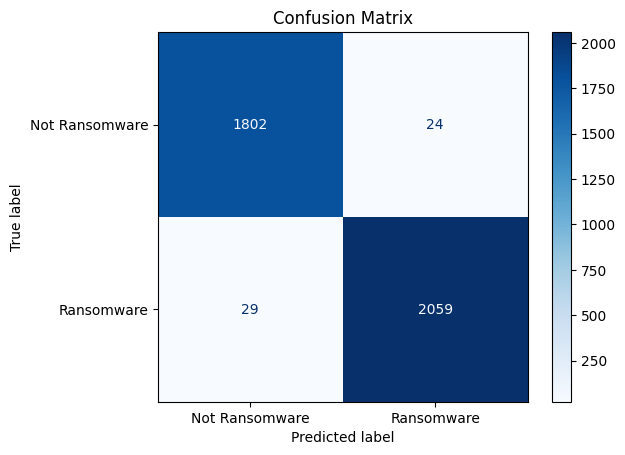

In [ ]:
evaluate(DecisionTreeClassifier(random_state=42), X_train, y_train, X_test, y_test)

                precision    recall  f1-score   support

Not Ransomware       0.36      0.43      0.39      1895
    Ransomware       0.26      0.21      0.23      1855

      accuracy                           0.32      3750
     macro avg       0.31      0.32      0.31      3750
  weighted avg       0.31      0.32      0.31      3750



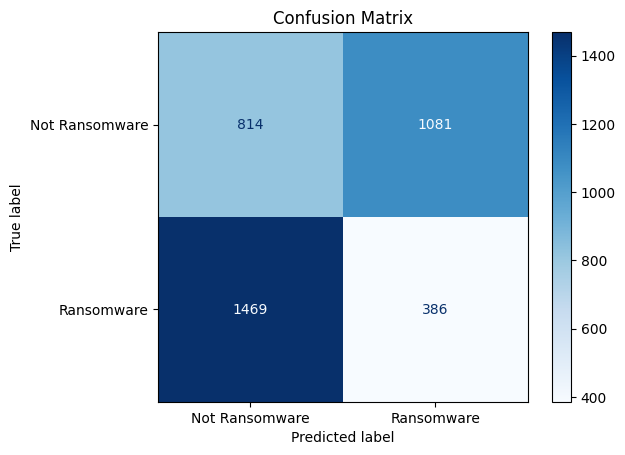

In [ ]:
evaluate(DecisionTreeClassifier(random_state=42), X_train, y_train, unseen_features, unseen_target)

### Support Vector Machine

                precision    recall  f1-score   support

Not Ransomware       0.98      0.97      0.98      1826
    Ransomware       0.98      0.99      0.98      2088

      accuracy                           0.98      3914
     macro avg       0.98      0.98      0.98      3914
  weighted avg       0.98      0.98      0.98      3914



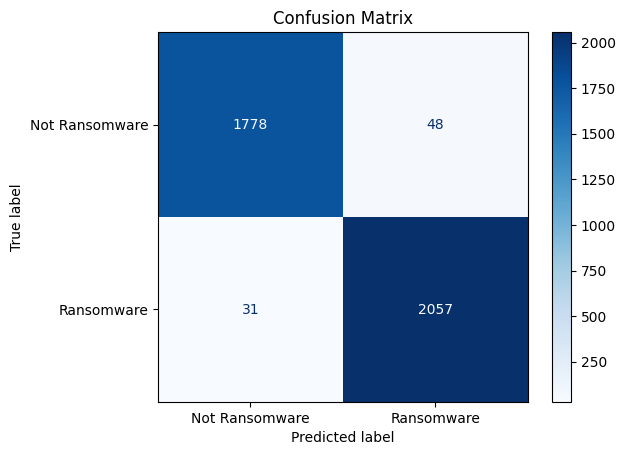

In [ ]:
evaluate(SVC(random_state=42), X_train, y_train, X_test, y_test)

                precision    recall  f1-score   support

Not Ransomware       0.41      0.53      0.46      1895
    Ransomware       0.30      0.21      0.25      1855

      accuracy                           0.37      3750
     macro avg       0.35      0.37      0.35      3750
  weighted avg       0.36      0.37      0.35      3750



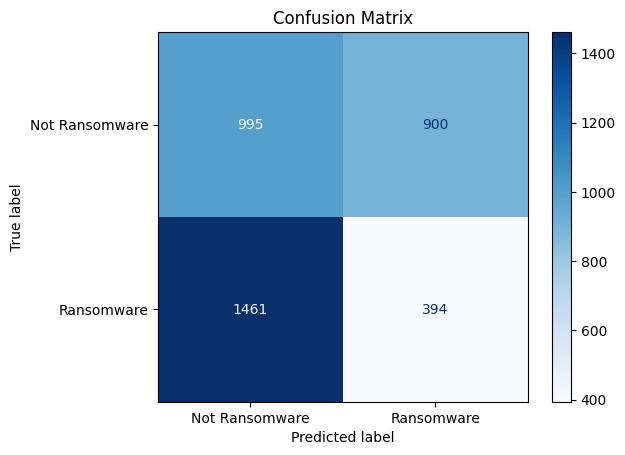

In [ ]:
evaluate(SVC(random_state=42), X_train, y_train, unseen_features, unseen_target)

### Neural Network

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                precision    recall  f1-score   support

Not Ransomware       0.98      0.99      0.99      1826
    Ransomware       0.99      0.98      0.99      2088

      accuracy                           0.99      3914
     macro avg       0.99      0.99      0.99      3914
  weighted avg       0.99      0.99      0.99      3914



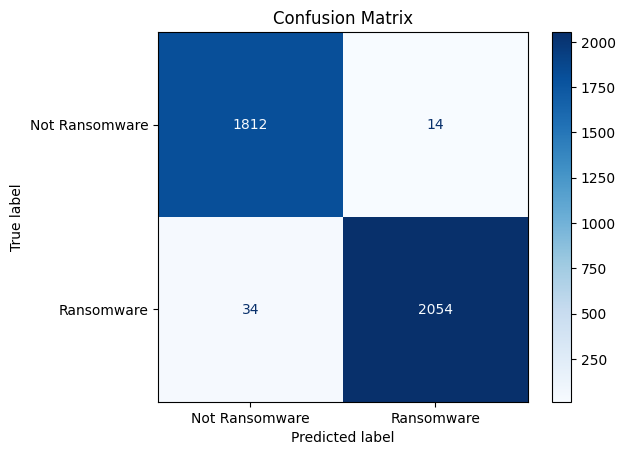

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Not Ransomware', 'Ransomware']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                precision    recall  f1-score   support

Not Ransomware       0.37      0.48      0.42      1895
    Ransomware       0.26      0.19      0.22      1855

      accuracy                           0.33      3750
     macro avg       0.32      0.33      0.32      3750
  weighted avg       0.32      0.33      0.32      3750



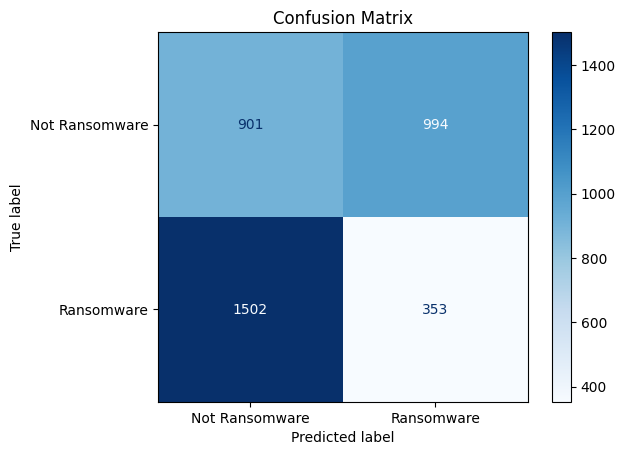

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_prob = model.predict(unseen_features)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(unseen_target, y_pred, target_names=['Not Ransomware', 'Ransomware']))

cm = confusion_matrix(unseen_target, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()